# 04.5 - Komparasi Klasifikasi: QLDE vs Standard K-Means (dan Metaheuristik Lain)

**Tujuan Analisis:**
Tahap ini adalah pembuktian akhir untuk melihat algoritma *clustering* mana yang menghasilkan segmentasi pelanggan yang paling terstruktur dan mudah diprediksi oleh AI. Kita akan mengadu metode dari paper referensi (**QLDE**) melawan *baseline* kelompok kita (**Standard**), beserta metode metaheuristik lainnya.

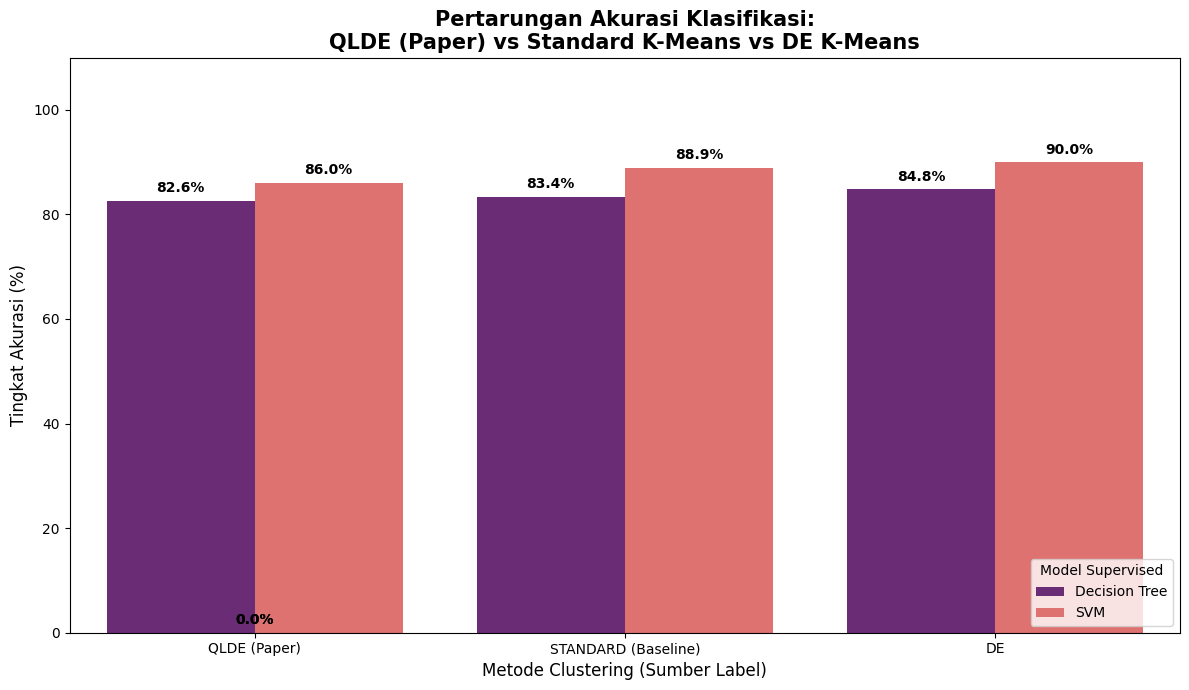

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 1. Daftar semua file hasil clustering di folder Labeled
file_datasets = {
    'QLDE (Paper)': '../data/Labeled/hasildata_kmeans-qlde.csv',
    'STANDARD (Baseline)': '../data/Labeled/hasildata_kmeans-standard.csv',
    'DE': '../data/Labeled/hasildata_kmeans-de.csv'
}

data_hasil = []

# 2. Looping pengujian ke semua dataset
for nama_metode, filepath in file_datasets.items():
    if not os.path.exists(filepath):
        print(f"File {filepath} tidak ditemukan. Lewati...")
        continue
        
    df = pd.read_csv(filepath)
    fitur = [f'Var{i}' for i in range(1, 12)]
    X = df[fitur]
    y = df['Cluster']
    
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # --- A. Prediksi Decision Tree ---
    model_dt = DecisionTreeClassifier(random_state=42, max_depth=4)
    model_dt.fit(X_train, y_train)
    akurasi_dt = accuracy_score(y_test, model_dt.predict(X_test))
    
    data_hasil.append({
        'Sumber Label': nama_metode, 
        'Algoritma': 'Decision Tree', 
        'Akurasi': akurasi_dt * 100
    })
    
    # --- B. Prediksi SVM ---
    # Batasi sampel 2000 baris
    X_train_svm, y_train_svm = X_train[:2000], y_train[:2000]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_svm)
    X_test_scaled = scaler.transform(X_test)
    
    # Class weight balanced untuk menghindari warning metrics
    model_svm = SVC(kernel='rbf', random_state=42, class_weight='balanced')
    model_svm.fit(X_train_scaled, y_train_svm)
    akurasi_svm = accuracy_score(y_test, model_svm.predict(X_test_scaled))
    
    data_hasil.append({
        'Sumber Label': nama_metode, 
        'Algoritma': 'SVM', 
        'Akurasi': akurasi_svm * 100
    })

# 3. Visualisasi Hasil
df_hasil = pd.DataFrame(data_hasil)

plt.figure(figsize=(12, 7))
grafik = sns.barplot(
    data=df_hasil, 
    x='Sumber Label', 
    y='Akurasi', 
    hue='Algoritma',
    palette='magma'
)

plt.title('Pertarungan Akurasi Klasifikasi:\nQLDE (Paper) vs Standard K-Means vs DE K-Means', 
          fontsize=15, fontweight='bold')
plt.xlabel('Metode Clustering (Sumber Label)', fontsize=12)
plt.ylabel('Tingkat Akurasi (%)', fontsize=12)
plt.ylim(0, 110)
plt.legend(title='Model Supervised', loc='lower right')

# Menampilkan angka persentase di atas batang grafik
for p in grafik.patches:
    grafik.annotate(f"{p.get_height():.1f}%", 
                   (p.get_x() + p.get_width() / 2., p.get_height()), 
                   ha='center', va='center', 
                   xytext=(0, 9), 
                   textcoords='offset points',
                   fontsize=10, fontweight='bold')

plt.tight_layout()
plt.show()

In [2]:
import pandas as pd
import time
import os
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

# 1. Daftar semua file dataset hasil clustering
file_datasets = {
    'QLDE (Paper)': '../data/Labeled/hasildata_kmeans-qlde.csv',
    'STANDARD (Baseline)': '../data/Labeled/hasildata_kmeans-standard.csv',
    'DE': '../data/Labeled/hasildata_kmeans-de.csv'
}

# Siapkan penampung untuk tabel hasil
tabel_hasil = []

# 2. Looping ke seluruh dataset
for nama_metode, filepath in file_datasets.items():
    if not os.path.exists(filepath):
        print(f"File {filepath} tidak ditemukan. Lewati...")
        continue
        
    df = pd.read_csv(filepath)
    fitur = [f'Var{i}' for i in range(1, 12)]
    X = df[fitur]
    y = df['Cluster']
    
    # Membagi Data (Seluruh data digunakan untuk DT)
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # ==========================================
    # A. Evaluasi Decision Tree (100% DATA KESELURUHAN)
    # ==========================================
    model_dt = DecisionTreeClassifier(random_state=42, max_depth=4)
    
    mulai_dt = time.time()
    val_acc_dt = cross_val_score(model_dt, X_train, y_train, cv=5).mean() * 100
    model_dt.fit(X_train, y_train)
    test_acc_dt = accuracy_score(y_test, model_dt.predict(X_test)) * 100
    selesai_dt = time.time()
    
    tabel_hasil.append({
        'Dataset': nama_metode,
        'Method': 'Decision Tree (DT)',
        'Validation Mean Accuracy (%)': round(val_acc_dt, 2),
        'Test Set Accuracy (%)': round(test_acc_dt, 2),
        'Time(second)': round(selesai_dt - mulai_dt, 4)
    })
    
    # ==========================================
    # B. Evaluasi Kernel SVM (BATAS AMAN 2000 DATA)
    # ==========================================
    # Mempertahankan batas 2000 sampel untuk mencegah processing delays / crash
    X_train_svm, y_train_svm = X_train[:2000], y_train[:2000]
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train_svm)
    X_test_scaled = scaler.transform(X_test)
    
    model_svm = SVC(kernel='rbf', random_state=42, class_weight='balanced')
    
    mulai_svm = time.time()
    val_acc_svm = cross_val_score(model_svm, X_train_scaled, y_train_svm, cv=5).mean() * 100
    model_svm.fit(X_train_scaled, y_train_svm)
    test_acc_svm = accuracy_score(y_test, model_svm.predict(X_test_scaled)) * 100
    selesai_svm = time.time()
    
    tabel_hasil.append({
        'Dataset': nama_metode,
        'Method': 'Kernel SVM (KSVM)',
        'Validation Mean Accuracy (%)': round(val_acc_svm, 2),
        'Test Set Accuracy (%)': round(test_acc_svm, 2),
        'Time(second)': round(selesai_svm - mulai_svm, 4)
    })

# ==========================================
# 3. CETAK HASIL SEBAGAI TABEL
# ==========================================
df_paper_metrics_all = pd.DataFrame(tabel_hasil)

# Menampilkan tabel komparasi akhir
df_paper_metrics_all

,Dataset,Method,Validation Mean Accuracy (%),Test Set Accuracy (%),Time(second)
0,QLDE (Paper),Decision Tree (DT),82.76,82.58,0.0416
1,QLDE (Paper),Kernel SVM (KSVM),86.90,86.04,0.1831
2,STANDARD (Baseline),Decision Tree (DT),84.75,83.39,0.0402
3,STANDARD (Baseline),Kernel SVM (KSVM),89.70,88.93,0.1599
4,DE,Decision Tree (DT),85.06,84.78,0.0386
5,DE,Kernel SVM (KSVM),90.30,89.97,0.1568
